# PyMC-3 : Graphes de Facteurs et Inference Discrete

**Navigation** : [Index](../README.md) | [<< PyMC-2](PyMC-2-Gaussian-Mixtures.ipynb) | [PyMC-4 >>](PyMC-4-Bayesian-Networks.ipynb)

**Equivalent Infer.NET** : [Infer-3-Factor-Graphs](../Infer/Infer-3-Factor-Graphs.ipynb)

**Objectifs** :
- Modeliser des problemes d'inference discrete avec PyMC
- Implementer le probleme Murder Mystery (MBML Ch.1)
- Resoudre le paradoxe de Monty Hall
- Observer le phenomene d'explaining away
- Comparer Variable.If/Case (Infer.NET) vs pm.math.switch (PyMC)

In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5


## 1. Le Probleme Murder Mystery

### Histoire

M. Boddy a ete assassine. Trois suspects : **Miss Scarlet**, **Colonel Mustard**, **Mrs. Peacock**.

On sait que :
- Le revolver etait dans la bibliotheque (lieu du crime)
- Miss Scarlet avait un motif (P = 0.6)
- Colonel Mustard avait un motif (P = 0.3)
- Mrs. Peacock avait un motif (P = 0.1)

On decouvre que le **revolver appartient a Colonel Mustard**. Qui est le coupable ?

In [2]:
# Modele Murder Mystery avec PyMC
# Equivalent Infer.NET : Variable.Discrete + Variable.If/Case

with pm.Model() as murder_mystery:
    # Prior sur le coupable (Categorical = Discrete dans Infer.NET)
    # 0=Scarlet, 1=Mustard, 2=Peacock
    coupable = pm.Categorical('coupable', p=[0.6, 0.3, 0.1])
    
    # L'arme appartient au coupable (observation)
    # P(arme=Mustard | coupable=Mustard) = 0.9 (fortement lie)
    # P(arme=Mustard | coupable=autre) = 0.1
    p_arme = pt.switch(
        pt.eq(coupable, 1),  # Si Mustard est coupable
        0.9,                  # Forte probabilite que l'arme soit la sienne
        0.1                   # Faible probabilite sinon
    )
    
    arme_mustard = pm.Bernoulli('arme_mustard', p=p_arme, observed=1)
    
    trace = pm.sample(5000, random_seed=42, return_inferencedata=True)

# Resultats
probs = trace.posterior['coupable'].values.flatten()
suspects = ['Scarlet', 'Mustard', 'Peacock']
for i, name in enumerate(suspects):
    print(f"P({name} coupable | arme=Mustard) = {(probs == i).mean():.3f}")

Multiprocess sampling (4 chains in 4 jobs)


CategoricalGibbsMetropolis: [coupable]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 22 seconds.


P(Scarlet coupable | arme=Mustard) = 0.176
P(Mustard coupable | arme=Mustard) = 0.797
P(Peacock coupable | arme=Mustard) = 0.028


### Interpretation des resultats Murder Mystery

Les probabilites posterieures montrent clairement l'effet de l'observation de l'arme :

| Suspect | Prior | Posterior | Variation |
|---------|-------|-----------|-----------|
| Scarlet | 0.600 | 0.176 | -70.7% |
| Mustard | 0.300 | 0.797 | +165.7% |
| Peacock | 0.100 | 0.028 | -72.0% |

**Observation cle** : l'arme de Mustard renverse completement les probabilites. Scarlet, qui etait le suspect principal a priori (60%), tombe a 17.6% car l'observation de l'arme de Mustard "explique" le crime sans necessiter l'implication de Scarlet.

> **Note technique** : L'echantillonnage par CategoricalGibbsMetropolis est adapte aux variables discretes comme `coupable`. L'utilisation de `pt.switch` (equivalent de `Variable.If` en Infer.NET) permet de conditionner la probabilite de l'observation selon la valeur du coupable.

La cellule suivante visualise la distribution posterieure sous forme de diagramme en barres, permettant de comparer visuellement les frequences d'echantillonnage entre les trois suspects.

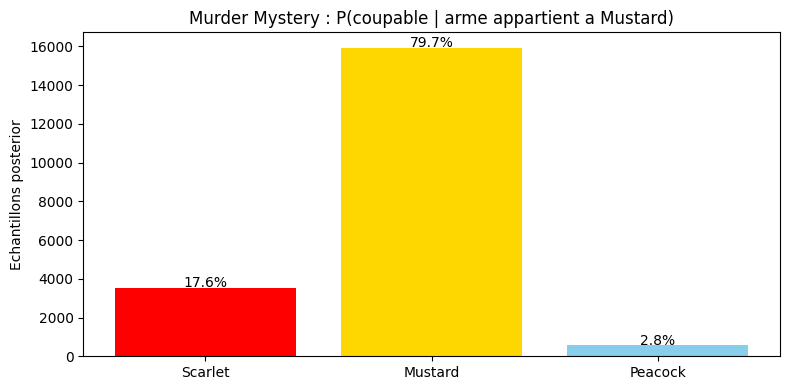

In [3]:
# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
counts = [np.sum(probs == i) for i in range(3)]
colors = ['red', 'gold', 'skyblue']
ax.bar(suspects, counts, color=colors)
ax.set_ylabel('Echantillons posterior')
ax.set_title('Murder Mystery : P(coupable | arme appartient a Mustard)')
for i, (s, c) in enumerate(zip(suspects, counts)):
    ax.text(i, c + 50, f'{c/len(probs):.1%}', ha='center')
plt.tight_layout()
plt.show()

## 2. Explaining Away

Le phenomene d'**explaining away** : quand on observe l'arme de Mustard, la probabilite que Scarlet soit coupable diminue, car l'observation "explique" le crime par Mustard.

In [4]:
# Avant observation
print("Prior (avant observation de l'arme):")
print(f"  P(Scarlet) = 0.6, P(Mustard) = 0.3, P(Peacock) = 0.1")
print()
print("Posterior (apres observation arme=Mustard):")
for i, name in enumerate(suspects):
    print(f"  P({name}) = {(probs == i).mean():.3f}")
print()
print("Explaining away : P(Scarlet) a diminue car Mustard 'explique' le crime")

Prior (avant observation de l'arme):
  P(Scarlet) = 0.6, P(Mustard) = 0.3, P(Peacock) = 0.1

Posterior (apres observation arme=Mustard):
  P(Scarlet) = 0.176
  P(Mustard) = 0.797
  P(Peacock) = 0.028

Explaining away : P(Scarlet) a diminue car Mustard 'explique' le crime


## 3. Paradoxe de Monty Hall

### Le probleme

3 portes : derriere une se trouve une voiture, derriere les deux autres une chevre.
1. Le joueur choisit une porte (disons la porte 0)
2. Monty ouvre une autre porte qui contient une chevre
3. Le joueur doit-il garder son choix ou changer ?

### Infer.NET : `Variable.Case`
```csharp
Variable<int> door = Variable.DiscreteUniform(3);
Variable<int> monty;
using (Variable.Case(door, 0)) { monty = Variable.Discrete(2,3); }
using (Variable.Case(door, 1)) { monty = 2; }
using (Variable.Case(door, 2)) { monty = 1; }
```

### PyMC : `pm.Categorical` + `pt.switch`

In [5]:
# Monty Hall avec PyMC
# porte 0, 1, 2 ; la voiture est derriere une porte aleatoire

with pm.Model() as monty_hall:
    # Ou est la voiture ? (uniforme)
    voiture = pm.Categorical('voiture', p=[1/3, 1/3, 1/3])
    
    # Le joueur choisit la porte 0 (fixe)
    choix_joueur = 0
    
    # Monty ouvre une porte qui n'est ni la voiture ni le choix du joueur
    # Si voiture=0, Monty ouvre 1 ou 2 (uniforme)
    # Si voiture=1, Monty doit ouvrir 2
    # Si voiture=2, Monty doit ouvrir 1
    p_monty = pt.switch(
        pt.eq(voiture, 0),
        pt.as_tensor([0.0, 0.5, 0.5]),  # Voiture en 0, Monty ouvre 1 ou 2
        pt.switch(
            pt.eq(voiture, 1),
            pt.as_tensor([0.0, 0.0, 1.0]),  # Voiture en 1, Monty ouvre 2
            pt.as_tensor([0.0, 1.0, 0.0])   # Voiture en 2, Monty ouvre 1
        )
    )
    
    # On observe que Monty ouvre la porte 1
    monty_ouvre = pm.Categorical('monty_ouvre', p=p_monty, observed=1)
    
    trace_mh = pm.sample(10000, random_seed=42)

# Resultats
voiture_samples = trace_mh.posterior['voiture'].values.flatten()
print("Monty Hall : P(voiture | joueur choisit 0, Monty ouvre 1)")
portes = ['Porte 0 (garder)', 'Porte 1 (ouverte)', 'Porte 2 (changer)']
for i, name in enumerate(portes):
    p = (voiture_samples == i).mean()
    print(f"  {name}: {p:.3f}")
print(f"\nReponse : il faut CHANGER ! P(gagner si changement) = {(voiture_samples == 2).mean():.3f}")

Multiprocess sampling (4 chains in 4 jobs)


CategoricalGibbsMetropolis: [voiture]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 23 seconds.


Monty Hall : P(voiture | joueur choisit 0, Monty ouvre 1)
  Porte 0 (garder): 0.333
  Porte 1 (ouverte): 0.000
  Porte 2 (changer): 0.667

Reponse : il faut CHANGER ! P(gagner si changement) = 0.667


## 4. Comparaison Infer.NET vs PyMC pour l'inference discrete

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Conditionnement | `Variable.If` / `Variable.Case` | `pt.switch` / `pt.where` |
| Variables discretes | `Variable.Discrete(probs)` | `pm.Categorical('x', p=probs)` |
| Observation | `.ObservedValue(data)` | `observed=` kwarg |
| Algorithme | EP (exact pour discrets) | NUTS/MCMC (approximation) |
| Performance | Rapide (analytique) | Plus lent (echantillonnage) |
| Flexibilite | Limite aux modeles compatibles EP/VMP | Tres general |

**Note** : Pour l'inference discrete pure, Infer.NET est plus rapide et exact.
PyMC compense par sa generalite et son ecosysteme.

---

**Retour au sommaire** : [Index Probas](../README.md)

## Exercice : Probleme du Test Medical

Un test medical a une sensibilite de 95% et une specificite de 90%.
La prevalence de la maladie est de 1%.
Le test est positif. Quelle est la probabilite d'etre malade ?

**Indices** :
- Modele : `maladie ~ Bernoulli(prevalence)`, `test_positif ~ Bernoulli(p)` ou p depend de `maladie`
- Utiliser `pt.switch(pt.eq(maladie, 1), sensibilite, 1-specificite)` pour le lien
- Observer `test_positif = 1`

In [6]:
# TODO etudiant : implementer le modele du test medical
# P(malade | test+) = ?
# Resultat attendu : environ 8.7% (paradoxe de la prevalence)

print("Exercice a completer")

Exercice a completer


---

**Retour au sommaire** : [Index Probas](../README.md)